In [1]:
import os
import shutil

# ==========================
# PATHS
# ==========================
source_dataset = "C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\archive (3)\\dataset-resized"
new_dataset = "C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\smart_city_dataset"

# Create new folders
bio_path = os.path.join(new_dataset, "biodegradable")
non_bio_path = os.path.join(new_dataset, "non_biodegradable")

os.makedirs(bio_path, exist_ok=True)
os.makedirs(non_bio_path, exist_ok=True)

# ==========================
# CATEGORY MAPPING
# ==========================
biodegradable_classes = [
    "Paper",
    "Cardboard",
    "Clothes"
]

non_biodegradable_classes = [
    "Plastic",
    "Glass",
    "Metal",
    "Battery"
]

# ==========================
# COPY FILES
# ==========================
def copy_images(classes, destination_folder):
    for cls in classes:
        class_path = os.path.join(source_dataset, cls)

        if os.path.exists(class_path):
            for img in os.listdir(class_path):
                src = os.path.join(class_path, img)

                if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                    dst = os.path.join(
                        destination_folder,
                        f"{cls}_{img}"
                    )

                    shutil.copy(src, dst)

copy_images(biodegradable_classes, bio_path)
copy_images(non_biodegradable_classes, non_bio_path)

print("Dataset converted successfully!")

Dataset converted successfully!


In [2]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

# ==========================
# PATHS
# ==========================
dataset_path = "C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\smart_city_dataset"
output_path = "C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\final_dataset"

# Create folders
for split in ['train', 'val', 'test']:
    for category in ['biodegradable', 'non_biodegradable']:
        os.makedirs(
            os.path.join(output_path, split, category),
            exist_ok=True
        )

# ==========================
# SPLIT DATA
# ==========================
categories = ['biodegradable', 'non_biodegradable']

for category in categories:
    category_path = os.path.join(dataset_path, category)

    images = [
        img for img in os.listdir(category_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(images)

    # 70% train, 15% val, 15% test
    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )

    split_dict = {
        'train': train_imgs,
        'val': val_imgs,
        'test': test_imgs
    }

    # Copy images
    for split_name, split_images in split_dict.items():
        split_folder = os.path.join(
            output_path,
            split_name,
            category
        )

        for img in split_images:
            src = os.path.join(category_path, img)
            dst = os.path.join(split_folder, img)
            shutil.copy(src, dst)

print("Train/Validation/Test split completed!")

Train/Validation/Test split completed!


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ==========================
# PATHS
# ==========================
train_dir = "C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\final_dataset\\train"
val_dir = "C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\final_dataset\\val"
test_dir = "C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\final_dataset\\test"

# ==========================
# IMAGE SETTINGS
# ==========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ==========================
# DATA AUGMENTATION
# ==========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ==========================
# MODEL
# ==========================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# ==========================
# COMPILE
# ==========================
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================
# CALLBACKS
# ==========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# ==========================
# TRAIN MODEL
# ==========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

# ==========================
# TEST MODEL
# ==========================
loss, accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {accuracy*100:.2f}%")

Found 2192 images belonging to 2 classes.
Found 661 images belonging to 2 classes.
Found 662 images belonging to 2 classes.
Epoch 1/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.7269 - loss: 0.5551
Epoch 1: val_accuracy improved from None to 0.95915, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 49s 678ms/step - accuracy: 0.8339 - loss: 0.3929 - val_accuracy: 0.9592 - val_loss: 0.1755
Epoch 2/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9287 - loss: 0.1932
Epoch 2: val_accuracy improved from 0.95915 to 0.96369, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 29s 416ms/step - accuracy: 0.9339 - loss: 0.1814 - val_accuracy: 0.9637 - val_loss: 0.1195
Epoch 3/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9559 - loss: 0.1469
Epoch 3: val_accuracy improved from 0.96369 to 0.96823, saving model to best_model.keras

Epoch 3: fini

In [4]:
print(train_data.class_indices)

{'biodegradable': 0, 'non_biodegradable': 1}


In [5]:
{
 'biodegradable': 0,
 'non_biodegradable': 1
}

{'biodegradable': 0, 'non_biodegradable': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step


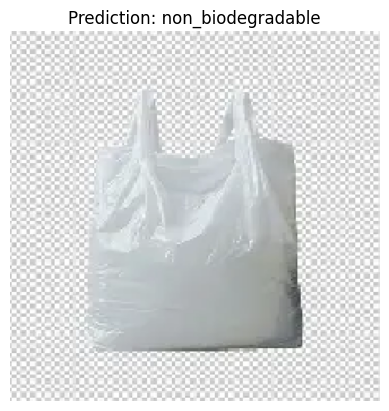

Prediction Score: 0.66413176
Predicted Class: non_biodegradable


In [9]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model
model = load_model("C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\best_model.keras")
# Image path
img_path = "C:\\Users\\user\\OneDrive\\Desktop\\Project - Grabage\\image.png"

# Load image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediction
prediction = model.predict(img_array)[0][0]

# FIXED LABELS
if prediction < 0.5:
    result = "biodegradable"
else:
    result = "non_biodegradable"

# Show image
plt.imshow(img)
plt.title(f"Prediction: {result}")
plt.axis("off")
plt.show()

print("Prediction Score:", prediction)
print("Predicted Class:", result)

In [2]:
# --- Save in Keras 3 style ---
# Use .keras (recommended) or .h5
model.save("garbage_model.keras")   # modern format
# OR
# model.save("garbage_model.h5")    # legacy format

# --- Load safely ---
loaded_model = tf.keras.models.load_model("garbage_model.keras")
# OR
# loaded_model = tf.keras.models.load_model("garbage_model.h5")


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
